In [1]:
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [2]:
data=[]
for i in range(250):
    study_hours = random.randint(1, 10)
    attendance = random.randint(50, 100)
    previous_marks = random.randint(30, 95)
    assignment_score = random.randint(30,100)
    marks=(
        study_hours * 4
        + attendance * 0.25
        + previous_marks * 0.45
        + assignment_score * 0.20
    )
    marks += random.randint(-5, 5)
    marks = max(0, min(100, round(marks)))
    data.append([
        study_hours,
        attendance,
        previous_marks,
        assignment_score,
        marks
    ])
    df = pd.DataFrame(
    data,
    columns=[
        "StudyHours",
        "Attendance",
        "PreviousMarks",
        "AssignmentScore",
        "Marks"
    ]
)

df.to_csv("student_data.csv", index=False)
print("student_data.csv created successfully!")
print(df.head())



student_data.csv created successfully!
   StudyHours  Attendance  PreviousMarks  AssignmentScore  Marks
0           6          52             74               42     79
1           5          69             59               70     76
2           1          87             44               76     66
3           6          74             60               59     84
4           1          53             54               77     56


In [3]:
print(df.tail())

     StudyHours  Attendance  PreviousMarks  AssignmentScore  Marks
245           2          98             44               53     67
246           8          71             78               93    100
247           4          68             36               71     68
248           9          64             51               49     80
249           6          63             77               65     88


In [4]:
df.describe()

,StudyHours,Attendance,PreviousMarks,AssignmentScore,Marks
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,5.424000,74.336000,62.432000,61.892000,80.328000
std,2.872845,14.714659,18.751101,20.405929,14.114435
min,1.000000,50.000000,30.000000,30.000000,43.000000
25%,3.000000,62.000000,47.000000,44.000000,70.250000
50%,6.000000,74.000000,62.500000,61.000000,81.000000
75%,8.000000,87.000000,78.000000,79.000000,92.000000
max,10.000000,100.000000,95.000000,100.000000,100.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   StudyHours       250 non-null    int64
 1   Attendance       250 non-null    int64
 2   PreviousMarks    250 non-null    int64
 3   AssignmentScore  250 non-null    int64
 4   Marks            250 non-null    int64
dtypes: int64(5)
memory usage: 9.9 KB


In [6]:
df=pd.read_csv("student_data.csv")

In [7]:
df

,StudyHours,Attendance,PreviousMarks,AssignmentScore,Marks
0,6,52,74,42,79
1,5,69,59,70,76
2,1,87,44,76,66
3,6,74,60,59,84
4,1,53,54,77,56
...,...,...,...,...,...
245,2,98,44,53,67
246,8,71,78,93,100
247,4,68,36,71,68
248,9,64,51,49,80


In [8]:
df.shape

(250, 5)

In [9]:
df.head()

,StudyHours,Attendance,PreviousMarks,AssignmentScore,Marks
0,6,52,74,42,79
1,5,69,59,70,76
2,1,87,44,76,66
3,6,74,60,59,84
4,1,53,54,77,56


In [10]:
df.columns

Index(['StudyHours', 'Attendance', 'PreviousMarks', 'AssignmentScore',
       'Marks'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   StudyHours       250 non-null    int64
 1   Attendance       250 non-null    int64
 2   PreviousMarks    250 non-null    int64
 3   AssignmentScore  250 non-null    int64
 4   Marks            250 non-null    int64
dtypes: int64(5)
memory usage: 9.9 KB


In [12]:
df.describe()

,StudyHours,Attendance,PreviousMarks,AssignmentScore,Marks
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,5.424000,74.336000,62.432000,61.892000,80.328000
std,2.872845,14.714659,18.751101,20.405929,14.114435
min,1.000000,50.000000,30.000000,30.000000,43.000000
25%,3.000000,62.000000,47.000000,44.000000,70.250000
50%,6.000000,74.000000,62.500000,61.000000,81.000000
75%,8.000000,87.000000,78.000000,79.000000,92.000000
max,10.000000,100.000000,95.000000,100.000000,100.000000


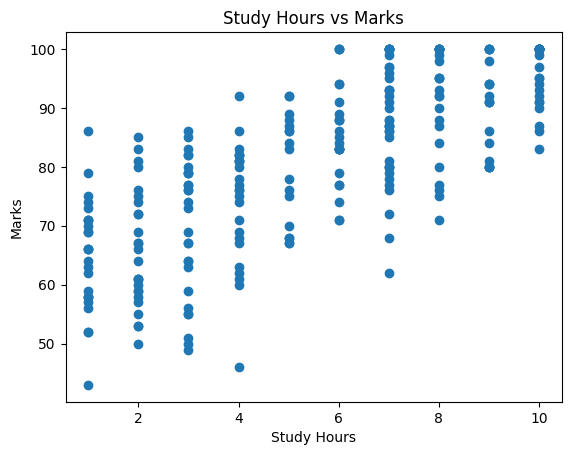

In [13]:

import matplotlib.pyplot as plt
plt.scatter(df["StudyHours"],df["Marks"])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")

plt.show()

In [14]:
X=df[
[
    "StudyHours",
    "Attendance",
    "PreviousMarks",
    "AssignmentScore" 
]
    ]
y=df["Marks"]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model.fit(X_train,y_train) #You are telling the model:“Learn the relationship between X (inputs) and y (output) using training data.”

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[3.78,0.23,0.39,0.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['StudyHours','Attendance','PreviousMarks','AssignmentScore']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.566
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [17]:
print(type(model))


<class 'sklearn.linear_model._base.LinearRegression'>


In [18]:
predictions = model.predict(X_test)

In [19]:
print(X.shape)
print(y.shape)

(250, 4)
(250,)


In [20]:
predictions[:5]

array([ 73.59871629, 103.57243047,  93.22516747,  85.64830991,
        77.27162303])

In [21]:
y_test[:5]

142     77
6      100
97      96
60      88
112     76
Name: Marks, dtype: int64

In [22]:
print(model.score(X_test, y_test))

0.9462163496376249


In [26]:
print(model)


LinearRegression()


In [27]:
y_pred = model.predict(X_test)
print(y_pred[:10])
print(y_test[:10])

[ 73.59871629 103.57243047  93.22516747  85.64830991  77.27162303
  89.68536359  85.17282088  99.65682116  92.90058782  67.71179772]
142     77
6      100
97      96
60      88
112     76
181     86
197     83
184    100
9       91
104     67
Name: Marks, dtype: int64


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.911470668342507
MSE: 10.825766766080156
RMSE: 3.2902532981641635
R2 Score: 0.9462163496376249


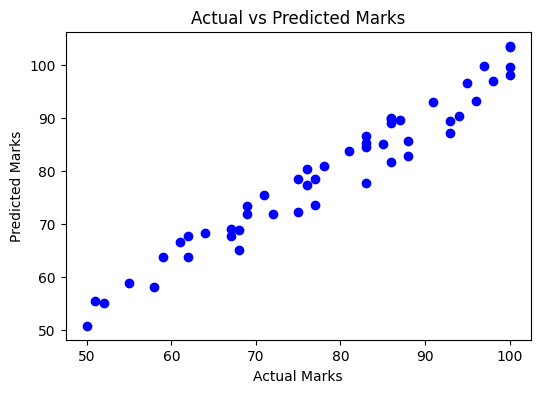

In [29]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()

In [30]:
errors = y_test - y_pred

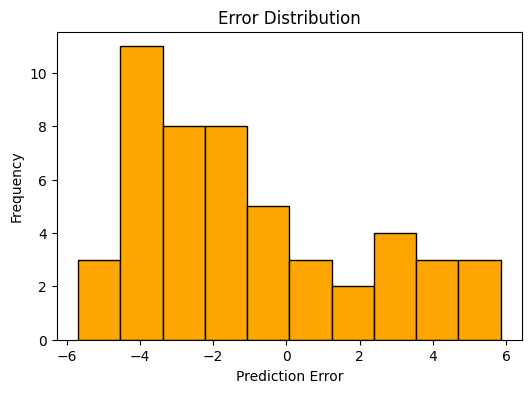

In [31]:
plt.figure(figsize=(6,4))
plt.hist(errors, bins=10, color='orange', edgecolor='black')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()